DATA6000 Capstone — SA Fresh Food Supply Disruption
Financial Year Analysis — Descriptive and Predictive
Libraries loaded successfully

STEP 3 — LOADING DATA
Excel not found ([Errno 2] No such file or directory: '/content/Final_Dataset_Filled.xlsx')
Using hardcoded data instead

Mastersheet: 5 financial years (2020/21 to 2024/25)

FY          Rainfall (mm)    Total (K t)    Veg (K t)  Fruit (K t)    CPI%
------------------------------------------------------------------------
2020/21            1829.4          998.1        746.8        251.2     2.3%
2021/22            2152.2         1015.8        756.4        259.3     1.9%
2022/23            2686.6         1007.3        755.9        251.5     9.2%
2023/24            1531.0         1037.5        791.7        245.8     4.5%
2024/25            1351.8         1018.1        775.9        242.1     3.0%

Processing daily rainfall data for FY 2025/26 estimate...
  Jul-Dec 2025 actual:              1160.2mm
  Historical Jul-Dec share of FY:  

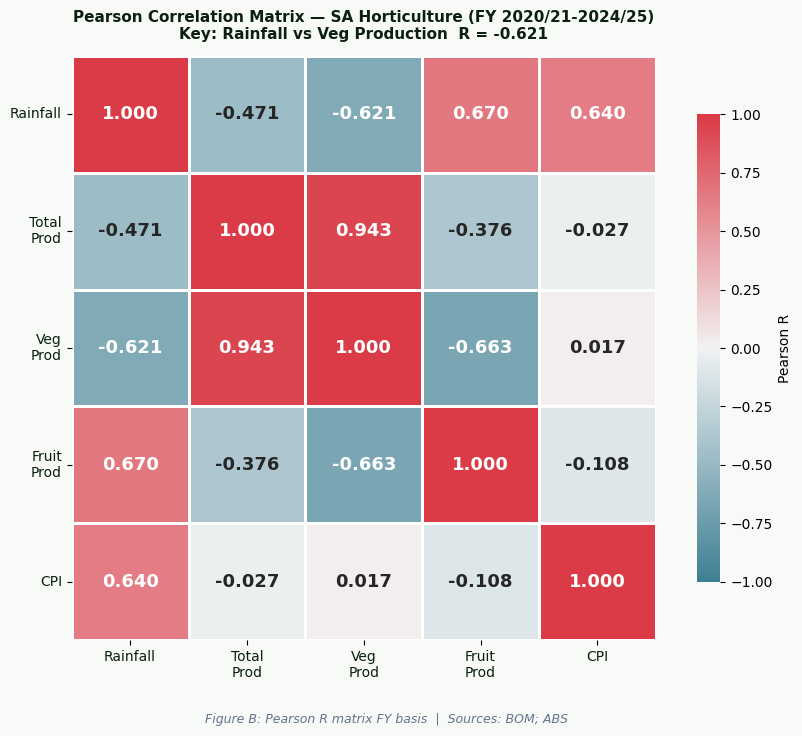

Saved: ChartA_Pearson_Heatmap.png


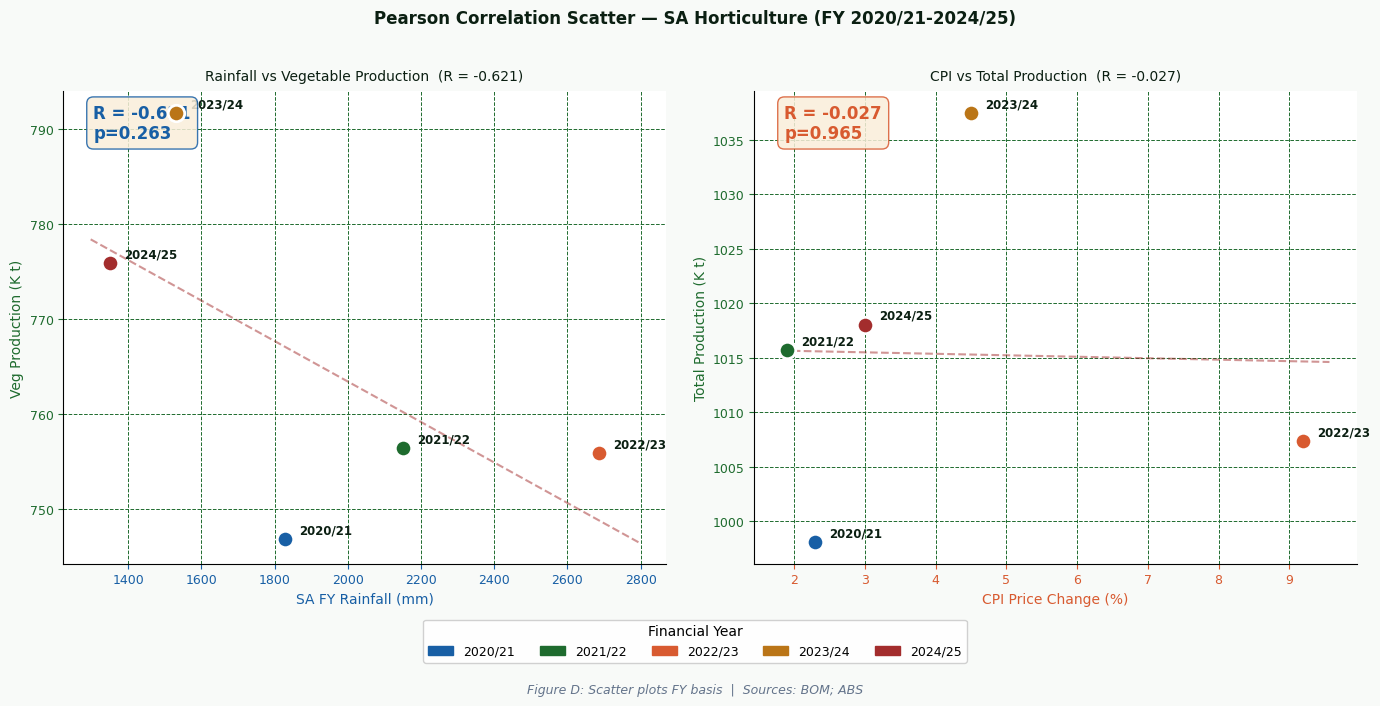

Saved: ChartA_Scatter.png

SECTION B — MULTIPLE LINEAR REGRESSION
Y = b0 + b1(Rainfall) + b2(CPI) + e

  Intercept (b0):          1,046,356.1
  Rainfall coef (b1):         -21.2257
  CPI coef (b2):                2282.5
  R-squared:                    0.3484
  RMSE:                          10.59K tonnes

SECTION C — ADF STATIONARITY TESTS
  Total Production                    ADF=  -2.158  p=0.2219  Non-stationary (d=1 applied)
  Total Rainfall                      ADF=  -1.034  p=0.7406  Non-stationary (d=1 applied)
  Veg Production                      ADF=  -1.241  p=0.6558  Non-stationary (d=1 applied)
  CPI                                 ADF=  -1.794  p=0.3833  Non-stationary (d=1 applied)

SECTION D — PREDICTIVE MODELS
Forecast: 2025/26 to 2029/30 (5 financial years)

  FY 2025/26 supporting data:
    Rainfall estimate: 1952mm (Jul-Dec 2025=1160mm / 59.4% seasonal share)
    CPI:               3.5% (calendar 2025)
    Note: Jan-Jun 2026 rainfall not yet available (current: Apri

INFO:prophet:n_changepoints greater than number of observations. Using 3.


  Alpha: 0.0000
  Beta:  0.0000
  RMSE: 10.67K t
  2025/26: 1033.9K (+15.8K)
  2026/27: 1040.0K (+22.0K)
  2027/28: 1046.2K (+28.1K)
  2028/29: 1052.4K (+34.3K)
  2029/30: 1058.5K (+40.5K)

MODEL D3 — PROPHET (Meta Bayesian)
  RMSE: 0.00K t
  2025/26: 998.7K (-19.4K)  CI:[944K–1050K]
  2026/27: 979.3K (-38.8K)  CI:[812K–1137K]
  2027/28: 959.9K (-58.2K)  CI:[673K–1229K]
  2028/29: 940.5K (-77.6K)  CI:[478K–1371K]
  2029/30: 921.1K (-97.0K)  CI:[259K–1506K]

SECTION E — MODEL COMPARISON

  Baseline (FY 2024/25): 1018.1K tonnes

  Model                              RMSE    25/26    26/27    27/28    28/29    29/30
  ------------------------------------------------------------------------------------
  ARIMA(1,1,0)                      18.66   1017.7   1017.7   1017.7   1017.7   1017.7
  Holt-Winters                      10.67   1033.9   1040.0   1046.2   1052.4   1058.5
  Prophet                            0.00    998.7    979.3    959.9    940.5    921.1

  Best in-sample fit: Prophet (

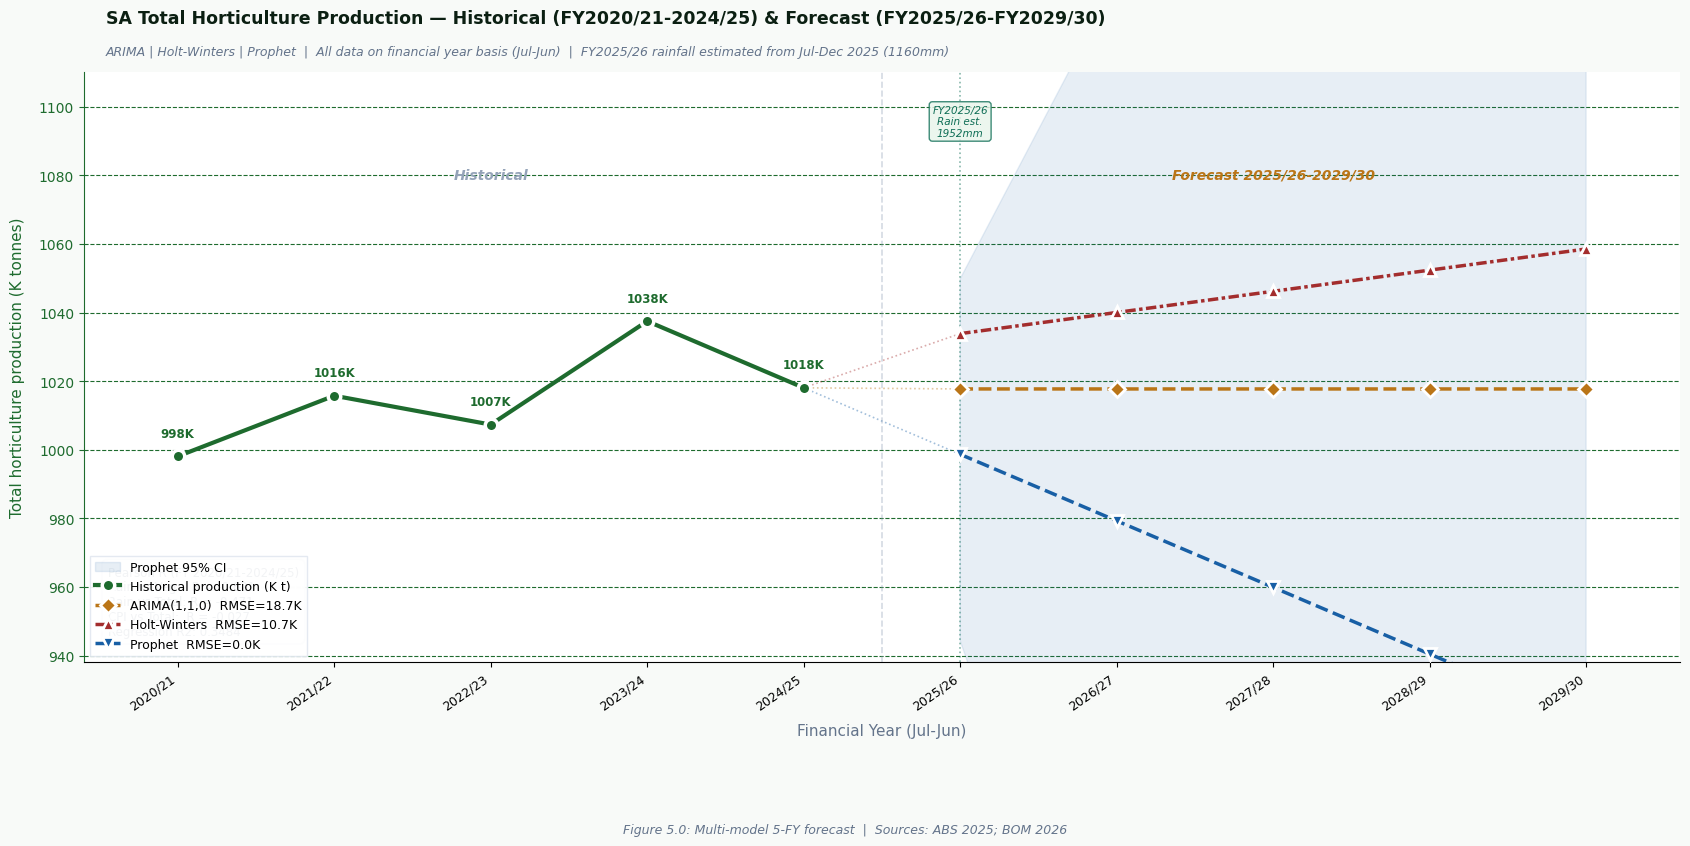

Saved: ChartI_MultiModel_Forecast.png


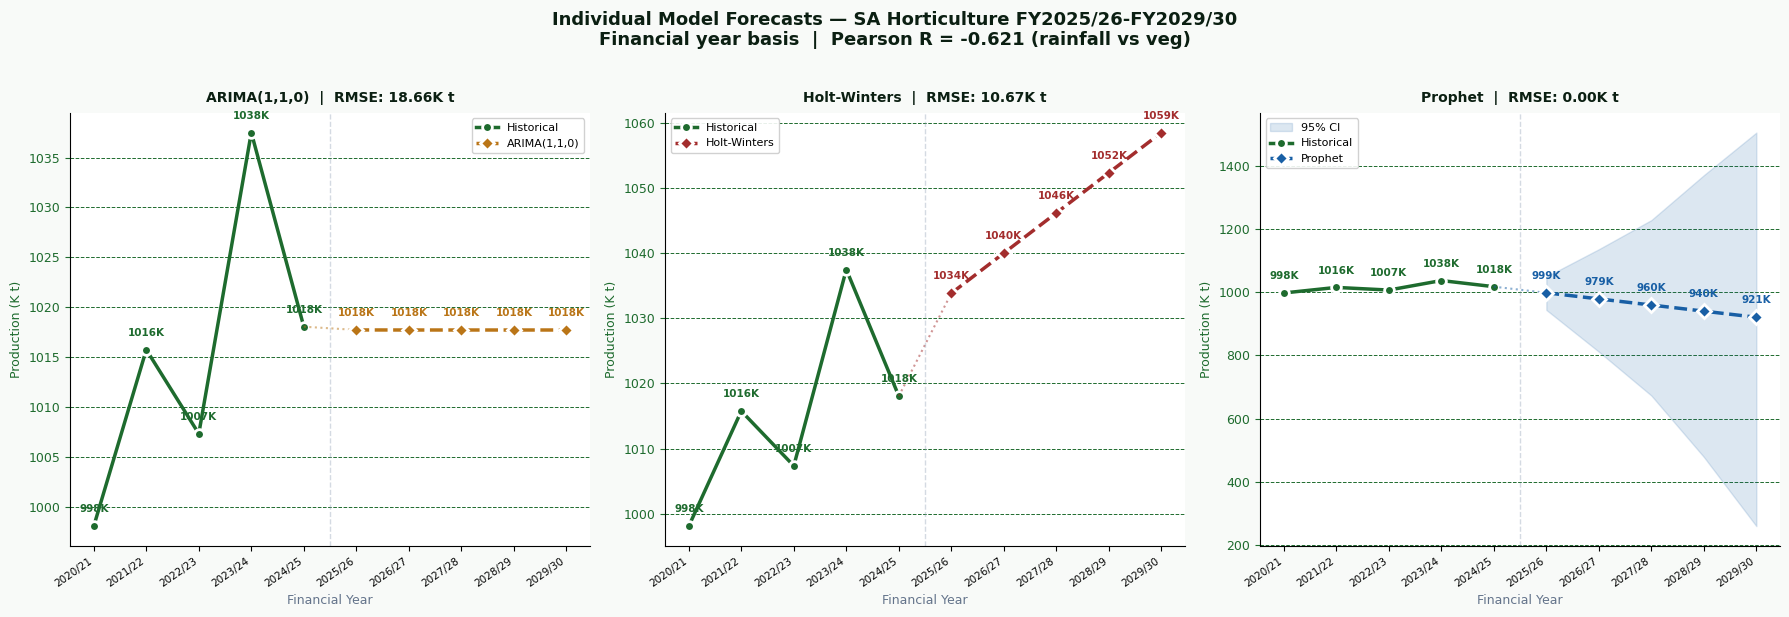

Saved: ChartI_Individual_Models.png


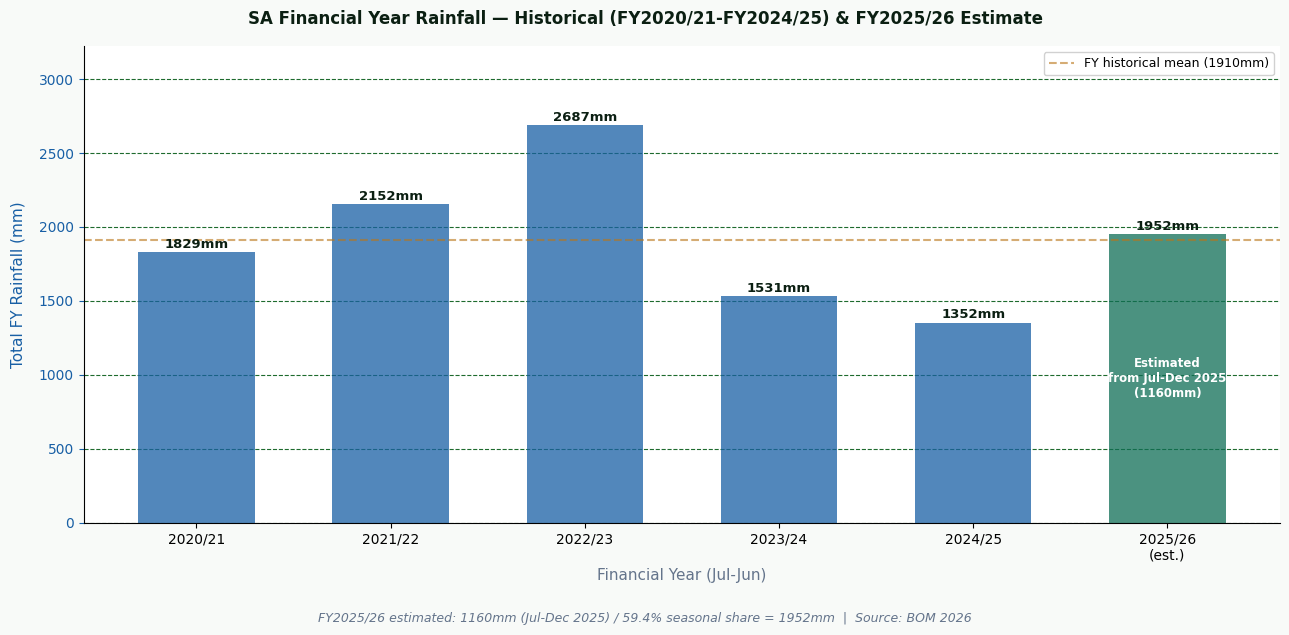

Saved: ChartR_Rainfall_FY.png

COMPLETE RESULTS SUMMARY — FINANCIAL YEAR BASIS

Training data:   FY 2020/21 to 2024/25 (5 FY)
Baseline:        FY 2024/25  1018.1K tonnes
Forecast:        FY 2025/26 to 2029/30 (5 FY)

All data on financial year (Jul-Jun) basis:
  Rainfall:    BOM daily data summed Jul-Jun
  Horticulture: ABS FY releases
  CPI:         Calendar year mapped to nearest FY

FY 2025/26 rainfall estimate: 1952mm
  Jul-Dec 2025:           1160.2mm observed
  Seasonal share applied: 59.4%

PEARSON R (FY 2020/21-2024/25):
  Rainfall vs Veg:     R = -0.621  p=0.2634
  Rainfall vs Total:   R = -0.471  p=0.4235
  CPI vs Total:        R = -0.027  p=0.9651
  Regression R2:       0.3484

FORECASTS (K tonnes):

  Model                              RMSE    25/26    26/27    27/28    28/29    29/30
  ------------------------------------------------------------------------------------------
  ARIMA(1,1,0)                      18.66   1017.7   1017.7   1017.7   1017.7   1017.7
  Holt-Winte

In [5]:
# ============================================================
# DATA6000 Capstone — SA Retail Fresh Food Supply Disruption
# Complete Financial Year Analysis
# Descriptive: 2020/21–2024/25 (5 FY)
# Predictive:  2025/26–2029/30 (5 FY forecast)
# Google Colab Ready
# ============================================================

# ── STEP 1: Install libraries ────────────────────────────────
# !pip install statsmodels matplotlib pandas numpy seaborn prophet openpyxl scikit-learn

# ── STEP 2: Imports ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model        import ARIMA
from statsmodels.tsa.holtwinters        import ExponentialSmoothing
from statsmodels.tsa.stattools          import adfuller
from sklearn.linear_model               import LinearRegression
from sklearn.metrics                    import mean_squared_error, r2_score
from prophet                            import Prophet
from scipy                              import stats

print("=" * 65)
print("DATA6000 Capstone — SA Fresh Food Supply Disruption")
print("Financial Year Analysis — Descriptive and Predictive")
print("=" * 65)
print("Libraries loaded successfully")

# ── COLOUR PALETTE ───────────────────────────────────────────
C_HIST  = '#1E6B2E'
C_ARIMA = '#BA7517'
C_HW    = '#A32D2D'
C_PRO   = '#185FA5'
C_CPI   = '#D85A30'
C_RAIN  = '#185FA5'
C_BG    = '#F8FAF8'
C_TITLE = '#0B1F12'
C_MUTED = '#64748B'
C_GRID  = (30/255, 107/255, 46/255, 0.07)
YR_COLS = ['#185FA5', '#1E6B2E', '#D85A30', '#BA7517', '#A32D2D']

# ============================================================
# STEP 3 — LOAD DATA
# ============================================================
print("\n" + "=" * 65)
print("STEP 3 — LOADING DATA")
print("=" * 65)

# Safe load — automatically falls back to hardcoded if file not found
try:
    xl = pd.read_excel('/content/Final_Dataset_Filled.xlsx', sheet_name=None)
    EXCEL_LOADED = True
    print(f"Excel loaded successfully — sheets: {list(xl.keys())}")
except Exception as e:
    xl = None
    EXCEL_LOADED = False
    print(f"Excel not found ({e})")
    print("Using hardcoded data instead")

# ── 3a: Mastersheet ──────────────────────────────────────────
if EXCEL_LOADED:
    ms = xl['Mastersheet'].copy()
else:
    ms = pd.DataFrame({
        'Year':                   ['2020/21','2021/22','2022/23','2023/24','2024/25'],
        'Total_Rainfall':         [1829.4,   2152.2,   2686.6,   1531.0,   1351.8  ],
        'Total_Fruit_Production': [251245.6, 259335.3, 251452.4, 245782.1, 242145.56],
        'Total_Veg_Production':   [746843.6, 756424.9, 755891.5, 791719.8, 775916.87],
        'Total_Production':       [998089.2, 1015760.2,1007343.9,1037501.9,1018062.43],
        'Price_Change':           [0.023,    0.019,    0.092,    0.045,    0.030],
    })

ms.set_index('Year', inplace=True)

def clean(val):
    if isinstance(val, str):
        return float(val.replace(',','').replace('%','').strip())
    return float(val)

for col in ms.columns:
    ms[col] = ms[col].apply(clean)

if ms['Price_Change'].max() < 1:
    ms['Price_Change'] = ms['Price_Change'] * 100
ms.rename(columns={'Price_Change': 'CPI'}, inplace=True)

fy_hist  = list(ms.index)
n_hist   = len(fy_hist)
prod_k   = ms['Total_Production']      / 1000
veg_k    = ms['Total_Veg_Production']  / 1000
fruit_k  = ms['Total_Fruit_Production'] / 1000
rainfall = ms['Total_Rainfall']
cpi      = ms['CPI']
baseline = float(prod_k.iloc[-1])
actual   = ms['Total_Production'].values[1:]   # n-1 = 4 for RMSE

print(f"\nMastersheet: {n_hist} financial years ({fy_hist[0]} to {fy_hist[-1]})")
print(f"\n{'FY':<10} {'Rainfall (mm)':>14} {'Total (K t)':>14} {'Veg (K t)':>12} {'Fruit (K t)':>12} {'CPI%':>7}")
print("-" * 72)
for fy in fy_hist:
    print(f"{fy:<10} {ms.loc[fy,'Total_Rainfall']:>14.1f} {prod_k[fy]:>14.1f} "
          f"{veg_k[fy]:>12.1f} {fruit_k[fy]:>12.1f} {cpi[fy]:>7.1f}%")

# ── 3b: Calculate FY 2025/26 rainfall from daily data ────────
print("\nProcessing daily rainfall data for FY 2025/26 estimate...")

if EXCEL_LOADED and 'Rainfall - 4 Suburbs' in xl:
    rf = xl['Rainfall - 4 Suburbs'].copy()
    rf['Year']  = rf['Year'].ffill()
    rf['Month'] = rf['Month'].ffill()
    rf = rf[rf['Year'] != 'Total'].copy()
    rf['Year'] = rf['Year'].astype(int)

    month_map = {
        'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
        'July':7,'August':8,'September':9,'October':10,'November':11,'December':12
    }
    rf['MonthNum'] = rf['Month'].map(month_map)
    rf = rf.dropna(subset=['Day','MonthNum']).copy()
    rf['Day']  = rf['Day'].astype(int)
    rf['Date'] = pd.to_datetime(dict(year=rf['Year'], month=rf['MonthNum'], day=rf['Day']))

    def to_fy(date):
        return f"{date.year}/{str(date.year+1)[2:]}" if date.month >= 7 else f"{date.year-1}/{str(date.year)[2:]}"

    rf['FY']     = rf['Date'].apply(to_fy)
    rf['HalfFY'] = rf['MonthNum'].apply(lambda m: 'JulDec' if m >= 7 else 'JanJun')

    seasonal = rf.groupby(['FY','HalfFY'])['Total_Rainfall'].sum().unstack(fill_value=0)
    seasonal['Total']      = seasonal['JanJun'] + seasonal['JulDec']
    seasonal['JulDec_pct'] = seasonal['JulDec'] / seasonal['Total']

    hist_fys_in_seasonal = [f for f in fy_hist if f in seasonal.index]
    avg_juldec_pct = float(seasonal.loc[hist_fys_in_seasonal, 'JulDec_pct'].mean())

    jul_dec_2025_26 = float(rf[(rf['FY']=='2025/26') & (rf['HalfFY']=='JulDec')]['Total_Rainfall'].sum())
    est_fy2526_rain = jul_dec_2025_26 / avg_juldec_pct
else:
    jul_dec_2025_26 = 1160.2
    avg_juldec_pct  = 0.594
    est_fy2526_rain = 1952.0

print(f"  Jul-Dec 2025 actual:              {jul_dec_2025_26:.1f}mm")
print(f"  Historical Jul-Dec share of FY:   {avg_juldec_pct*100:.1f}%")
print(f"  Estimated full FY 2025/26:        {est_fy2526_rain:.1f}mm")

# ── 3c: CPI for FY 2025/26 ───────────────────────────────────
if EXCEL_LOADED and 'CPI - SA' in xl:
    cpi_df = xl['CPI - SA'].copy()
    cpi_fy2526 = float(cpi_df[cpi_df['Year']==2025]['Price_Change'].values[0])
    if cpi_fy2526 < 1:
        cpi_fy2526 *= 100
else:
    cpi_fy2526 = 3.5

print(f"  CPI for FY 2025/26:               {cpi_fy2526:.1f}%")

# Forecast financial years
fy_fore = ['2025/26','2026/27','2027/28','2028/29','2029/30']
n_fore  = len(fy_fore)
all_fy  = fy_hist + fy_fore
x_hist  = list(range(n_hist))
x_fore  = list(range(n_hist, n_hist + n_fore))
x_all   = x_hist + x_fore
mid_x   = (x_hist[-1] + x_fore[0]) / 2

print(f"\n  Forecast: {fy_fore[0]} to {fy_fore[-1]} ({n_fore} financial years)")

# ============================================================
# SECTION A — PEARSON CORRELATION (DESCRIPTIVE)
# ============================================================
print("\n" + "=" * 65)
print("SECTION A — PEARSON CORRELATION (FY 2020/21-2024/25)")
print("=" * 65)

def pearson(x, y):
    r, p = stats.pearsonr(x.values, y.values)
    return r, p

r_rv, p_rv = pearson(rainfall, veg_k)
r_rt, p_rt = pearson(rainfall, prod_k)
r_rf, p_rf = pearson(rainfall, fruit_k)
r_ct, p_ct = pearson(cpi, prod_k)
r_cv, p_cv = pearson(cpi, veg_k)
r_rc, p_rc = pearson(rainfall, cpi)

print(f"\n  {'Variable pair':<42} {'R':>8}  {'p-value':>9}  Result")
print("  " + "-" * 72)
for nm, r, p in [
    ("Rainfall vs Veg production",    r_rv, p_rv),
    ("Rainfall vs Total production",  r_rt, p_rt),
    ("Rainfall vs Fruit production",  r_rf, p_rf),
    ("CPI vs Total production",       r_ct, p_ct),
    ("CPI vs Veg production",         r_cv, p_cv),
    ("Rainfall vs CPI",               r_rc, p_rc),
]:
    s = ("Very strong" if abs(r)>=0.8 else "Strong" if abs(r)>=0.6
         else "Moderate" if abs(r)>=0.4 else "Weak")
    d = "inverse" if r<0 else "positive"
    g = "p<0.05 sig" if p<0.05 else f"p={p:.3f} n/s"
    print(f"  {nm:<42} {r:>8.3f}  {p:>9.4f}  {s} {d} ({g})")

print(f"\n  KEY FINDING: R = {r_rv:.3f} (rainfall vs veg, FY basis)")

# Heatmap
corr_df = ms[['Total_Rainfall','Total_Production','Total_Veg_Production',
              'Total_Fruit_Production','CPI']].copy()
corr_df.columns = ['Rainfall','Total\nProd','Veg\nProd','Fruit\nProd','CPI']
fig1, ax1 = plt.subplots(figsize=(9,7))
fig1.patch.set_facecolor(C_BG)
ax1.set_facecolor('white')
sns.heatmap(corr_df.corr(), ax=ax1, annot=True, fmt='.3f',
            cmap=sns.diverging_palette(220,10,as_cmap=True),
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.8, linecolor='white',
            annot_kws={'size':13,'fontweight':'bold'},
            cbar_kws={'shrink':0.8,'label':'Pearson R'})
ax1.set_title(
    f'Pearson Correlation Matrix — SA Horticulture (FY 2020/21-2024/25)\n'
    f'Key: Rainfall vs Veg Production  R = {r_rv:.3f}',
    fontsize=11, fontweight='bold', color=C_TITLE, pad=12)
ax1.set_xticklabels(ax1.get_xticklabels(), fontsize=10, color=C_TITLE)
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=10, color=C_TITLE, rotation=0)
fig1.text(0.5,-0.04,'Figure B: Pearson R matrix FY basis  |  Sources: BOM; ABS',
          ha='center', fontsize=9, color=C_MUTED, style='italic')
plt.tight_layout()
plt.savefig('ChartA_Pearson_Heatmap.png', dpi=180, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("Saved: ChartA_Pearson_Heatmap.png")

# Scatter plots
fig2, axes2 = plt.subplots(1,2, figsize=(14,6))
fig2.patch.set_facecolor(C_BG)
fig2.suptitle('Pearson Correlation Scatter — SA Horticulture (FY 2020/21-2024/25)',
              fontsize=12, fontweight='bold', color=C_TITLE, y=1.02)

def draw_scatter(ax, xv, yv, xlabel, ylabel, r, p, col):
    ax.set_facecolor('white')
    for i,(x,y,lbl) in enumerate(zip(xv,yv,fy_hist)):
        ax.scatter(x,y,color=YR_COLS[i],s=140,zorder=5,edgecolors='white',linewidth=2)
        ax.annotate(lbl,(x,y),textcoords='offset points',xytext=(10,4),
                    fontsize=8.5,color=C_TITLE,fontweight='bold')
    z = np.polyfit(xv,yv,1)
    xl = np.linspace(min(xv)*0.96,max(xv)*1.04,100)
    ax.plot(xl,np.poly1d(z)(xl),color='#A32D2D',linewidth=1.5,linestyle='--',alpha=0.5)
    sig = "p<0.05" if p<0.05 else f"p={p:.3f}"
    ax.text(0.05,0.90,f'R = {r:.3f}\n{sig}',transform=ax.transAxes,
            fontsize=12,color=col,fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4',facecolor='#FAEEDA',edgecolor=col,alpha=0.85))
    ax.set_xlabel(xlabel,fontsize=10,color=col)
    ax.set_ylabel(ylabel,fontsize=10,color=C_HIST)
    ax.tick_params(axis='x',colors=col,labelsize=9)
    ax.tick_params(axis='y',colors=C_HIST,labelsize=9)
    ax.yaxis.grid(True,color=C_GRID,linestyle='--',linewidth=0.7)
    ax.xaxis.grid(True,color=C_GRID,linestyle='--',linewidth=0.7)
    ax.set_axisbelow(True)
    ax.spines[['top','right']].set_visible(False)

draw_scatter(axes2[0],rainfall.values,veg_k.values,
             'SA FY Rainfall (mm)','Veg Production (K t)',r_rv,p_rv,C_RAIN)
axes2[0].set_title(f'Rainfall vs Vegetable Production  (R = {r_rv:.3f})',fontsize=10,color=C_TITLE,pad=8)

draw_scatter(axes2[1],cpi.values,prod_k.values,
             'CPI Price Change (%)','Total Production (K t)',r_ct,p_ct,C_CPI)
axes2[1].set_title(f'CPI vs Total Production  (R = {r_ct:.3f})',fontsize=10,color=C_TITLE,pad=8)

handles = [mpatches.Patch(color=c,label=y) for c,y in zip(YR_COLS,fy_hist)]
fig2.legend(handles=handles,title='Financial Year',loc='lower center',
            ncol=5,fontsize=9,framealpha=0.9,bbox_to_anchor=(0.5,-0.08))
fig2.text(0.5,-0.12,'Figure D: Scatter plots FY basis  |  Sources: BOM; ABS',
          ha='center',fontsize=9,color=C_MUTED,style='italic')
plt.tight_layout()
plt.savefig('ChartA_Scatter.png', dpi=180, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("Saved: ChartA_Scatter.png")

# ============================================================
# SECTION B — MULTIPLE LINEAR REGRESSION
# ============================================================
print("\n" + "=" * 65)
print("SECTION B — MULTIPLE LINEAR REGRESSION")
print("Y = b0 + b1(Rainfall) + b2(CPI) + e")
print("=" * 65)

X_reg   = ms[['Total_Rainfall','CPI']].values
y_reg   = ms['Total_Production'].values
reg     = LinearRegression().fit(X_reg,y_reg)
y_pred  = reg.predict(X_reg)
r2_reg  = r2_score(y_reg,y_pred)
rmse_reg= np.sqrt(mean_squared_error(y_reg,y_pred))

print(f"\n  Intercept (b0):       {reg.intercept_:>14,.1f}")
print(f"  Rainfall coef (b1):   {reg.coef_[0]:>14.4f}")
print(f"  CPI coef (b2):        {reg.coef_[1]:>14.1f}")
print(f"  R-squared:            {r2_reg:>14.4f}")
print(f"  RMSE:                 {rmse_reg/1000:>14.2f}K tonnes")

# ============================================================
# SECTION C — STATIONARITY TESTS
# ============================================================
print("\n" + "=" * 65)
print("SECTION C — ADF STATIONARITY TESTS")
print("=" * 65)

def adf_test(series, name):
    res = adfuller(series, autolag='AIC')
    stat = "Stationary" if res[1]<0.05 else "Non-stationary (d=1 applied)"
    print(f"  {name:<35} ADF={res[0]:>8.3f}  p={res[1]:.4f}  {stat}")

adf_test(ms['Total_Production'],     'Total Production')
adf_test(ms['Total_Rainfall'],       'Total Rainfall')
adf_test(ms['Total_Veg_Production'], 'Veg Production')
adf_test(ms['CPI'],                  'CPI')

# ============================================================
# SECTION D — PREDICTIVE MODELS (5 FY FORECAST)
# ============================================================
print("\n" + "=" * 65)
print("SECTION D — PREDICTIVE MODELS")
print(f"Forecast: {fy_fore[0]} to {fy_fore[-1]} (5 financial years)")
print("=" * 65)
print(f"""
  FY 2025/26 supporting data:
    Rainfall estimate: {est_fy2526_rain:.0f}mm (Jul-Dec 2025={jul_dec_2025_26:.0f}mm / {avg_juldec_pct*100:.1f}% seasonal share)
    CPI:               {cpi_fy2526:.1f}% (calendar 2025)
    Note: Jan-Jun 2026 rainfall not yet available (current: April 2026)
""")

# MODEL D1: ARIMA(1,1,0)
print("MODEL D1 — ARIMA(1,1,0)")
arima_m   = ARIMA(ms['Total_Production'], order=(1,1,0)).fit()
arima_f   = arima_m.forecast(steps=n_fore).values / 1000
arima_fit = arima_m.fittedvalues.values[1:]
arima_rmse= np.sqrt(mean_squared_error(actual, arima_fit))
print(f"  RMSE: {arima_rmse/1000:.2f}K t")
for fy,v in zip(fy_fore,arima_f):
    print(f"  {fy}: {v:.1f}K ({v-baseline:+.1f}K)")

# MODEL D2: HOLT-WINTERS
print("\nMODEL D2 — HOLT-WINTERS EXPONENTIAL SMOOTHING")
hw_m   = ExponentialSmoothing(ms['Total_Production'],trend='add',seasonal=None,
                               initialization_method='estimated').fit(optimized=True)
hw_f   = hw_m.forecast(steps=n_fore).values / 1000
hw_fit = hw_m.fittedvalues.values[1:]
hw_rmse= np.sqrt(mean_squared_error(actual,hw_fit))
alpha  = hw_m.params.get('smoothing_level',None)
beta   = hw_m.params.get('smoothing_trend',None)
print(f"  Alpha: {alpha:.4f}" if alpha else "  Alpha: N/A")
print(f"  Beta:  {beta:.4f}"  if beta  else "  Beta:  N/A")
print(f"  RMSE: {hw_rmse/1000:.2f}K t")
for fy,v in zip(fy_fore,hw_f):
    print(f"  {fy}: {v:.1f}K ({v-baseline:+.1f}K)")

# MODEL D3: PROPHET
print("\nMODEL D3 — PROPHET (Meta Bayesian)")
fy_start_yrs = [int(fy.split('/')[0]) for fy in fy_hist]
prophet_df   = pd.DataFrame({
    'ds': pd.to_datetime([f'{y}-07-01' for y in fy_start_yrs]),
    'y' : ms['Total_Production'].values.astype(float)
})
prophet_m = Prophet(yearly_seasonality=False,weekly_seasonality=False,
                    daily_seasonality=False,changepoint_prior_scale=0.5,
                    interval_width=0.95)
prophet_m.fit(prophet_df)

future_df  = prophet_m.make_future_dataframe(periods=n_fore, freq='YS-JUL')
prophet_fc = prophet_m.predict(future_df)

prophet_fore_rows = prophet_fc.iloc[n_hist:]
prophet_hist_rows = prophet_fc.iloc[:n_hist]

prophet_f  = prophet_fore_rows['yhat'].values / 1000
prophet_lo = prophet_fore_rows['yhat_lower'].values / 1000
prophet_hi = prophet_fore_rows['yhat_upper'].values / 1000

prophet_fit    = prophet_hist_rows['yhat'].values[1:]
min_len        = min(len(actual),len(prophet_fit))
prophet_rmse   = np.sqrt(mean_squared_error(actual[:min_len],prophet_fit[:min_len]))

print(f"  RMSE: {prophet_rmse/1000:.2f}K t")
for fy,v,lo,hi in zip(fy_fore,prophet_f,prophet_lo,prophet_hi):
    print(f"  {fy}: {v:.1f}K ({v-baseline:+.1f}K)  CI:[{lo:.0f}K–{hi:.0f}K]")

# ============================================================
# SECTION E — MODEL COMPARISON
# ============================================================
print("\n" + "=" * 65)
print("SECTION E — MODEL COMPARISON")
print("=" * 65)

all_models = [
    ("ARIMA(1,1,0)",            arima_rmse/1000,  *arima_f),
    ("Holt-Winters",            hw_rmse/1000,     *hw_f),
    ("Prophet",                 prophet_rmse/1000,*prophet_f),
]

print(f"\n  Baseline (FY 2024/25): {baseline:.1f}K tonnes")
hdr = "  {:<30} {:>8} ".format('Model','RMSE') + ' '.join(f"{fy[-5:]:>8}" for fy in fy_fore)
print(f"\n{hdr}")
print("  " + "-"*84)
for m in all_models:
    vals = ' '.join(f'{v:>8.1f}' for v in m[2:])
    print(f"  {m[0]:<30} {m[1]:>8.2f} {vals}")

best = min(all_models,key=lambda x:x[1])
print(f"\n  Best in-sample fit: {best[0]} (RMSE={best[1]:.2f}K)")

# ============================================================
# SECTION F — CHARTS
# ============================================================
print("\n" + "=" * 65)
print("SECTION F — GENERATING CHARTS")
print("=" * 65)

# Chart 1: Multi-model combined
fig3, ax3 = plt.subplots(figsize=(17,8))
fig3.patch.set_facecolor(C_BG)
ax3.set_facecolor('white')

ax3.fill_between(x_fore,prophet_lo,prophet_hi,color=C_PRO,alpha=0.10,
                 label='Prophet 95% CI',zorder=2)

ax3.plot(x_hist,prod_k.values,color=C_HIST,linewidth=3,
         marker='o',markersize=9,markerfacecolor=C_HIST,
         markeredgecolor='white',markeredgewidth=2.5,
         label='Historical production (K t)',zorder=7)
for xi,val in zip(x_hist,prod_k.values):
    ax3.annotate(f'{val:.0f}K',(xi,val),textcoords='offset points',
                 xytext=(0,14),ha='center',fontsize=8.5,color=C_HIST,fontweight='bold')

# Rainfall estimate annotation on 2025/26
ax3.axvline(x=x_fore[0],color='#0F6E56',linewidth=1.2,linestyle=':',alpha=0.5)
ax3.text(x_fore[0],float(prod_k.max())*1.052,
         f'FY2025/26\nRain est.\n{est_fy2526_rain:.0f}mm',
         ha='center',fontsize=7.5,color='#0F6E56',style='italic',
         bbox=dict(boxstyle='round,pad=0.3',facecolor='#E8F4EA',edgecolor='#0F6E56',alpha=0.8))

for fv,col in zip([arima_f[0],hw_f[0],prophet_f[0]],[C_ARIMA,C_HW,C_PRO]):
    ax3.plot([x_hist[-1],x_fore[0]],[baseline,fv],color=col,linewidth=1.2,linestyle=':',alpha=0.4)

model_lines = [
    (arima_f,  C_ARIMA,'--',          'D',f'ARIMA(1,1,0)  RMSE={arima_rmse/1000:.1f}K'),
    (hw_f,     C_HW,   (0,(3,1,1,1)),'^',f'Holt-Winters  RMSE={hw_rmse/1000:.1f}K'),
    (prophet_f,C_PRO,  '--',          'v',f'Prophet  RMSE={prophet_rmse/1000:.1f}K'),
]
for fore,col,ls,mk,lbl in model_lines:
    ax3.plot(x_fore,fore,color=col,linewidth=2.5,linestyle=ls,
             marker=mk,markersize=8,markerfacecolor=col,
             markeredgecolor='white',markeredgewidth=2,label=lbl,zorder=6)

ax3.axvline(x=mid_x,color='#94A3B8',linestyle='--',linewidth=1.2,alpha=0.4)
ax3.text(np.mean(x_hist),float(prod_k.max())*1.04,'Historical',ha='center',
         fontsize=10,color='#94A3B8',style='italic',fontweight='bold')
ax3.text(np.mean(x_fore),float(prod_k.max())*1.04,
         f'Forecast {fy_fore[0]}-{fy_fore[-1]}',ha='center',
         fontsize=10,color=C_ARIMA,style='italic',fontweight='bold')

ax3.set_ylim(float(prod_k.min())*0.94,float(prod_k.max())*1.07)
ax3.set_xlim(-0.6,len(x_all)-0.4)
ax3.set_xticks(x_all)
ax3.set_xticklabels(all_fy,rotation=35,ha='right',fontsize=9)
ax3.set_ylabel('Total horticulture production (K tonnes)',fontsize=11,color=C_HIST,labelpad=10)
ax3.tick_params(axis='y',colors=C_HIST,labelsize=10)
ax3.set_xlabel('Financial Year (Jul-Jun)',fontsize=11,color=C_MUTED,labelpad=8)
ax3.spines[['top','right']].set_visible(False)
ax3.spines['left'].set_color(C_HIST)
ax3.yaxis.grid(True,color=C_GRID,linestyle='--',linewidth=0.8)
ax3.set_axisbelow(True)
ax3.legend(loc='lower left',fontsize=9,framealpha=0.92,edgecolor='#E2E8F0',fancybox=False)

box = (f"Pearson R (FY 2020/21-2024/25)\n"
       f"Rain vs Veg:   R = {r_rv:.3f}\n"
       f"Rain vs Total: R = {r_rt:.3f}\n"
       f"CPI vs Total:  R = {r_ct:.3f}\n"
       f"Regression R2: {r2_reg:.4f}")
ax3.text(0.015,0.04,box,transform=ax3.transAxes,fontsize=8.5,color=C_MUTED,
         verticalalignment='bottom',
         bbox=dict(boxstyle='round,pad=0.5',facecolor='white',edgecolor='#E2E8F0',alpha=0.9))

fig3.text(0.065,0.97,
    f'SA Total Horticulture Production — Historical (FY2020/21-2024/25) & Forecast (FY2025/26-FY2029/30)',
    fontsize=12.5,fontweight='bold',color=C_TITLE,va='top')
fig3.text(0.065,0.925,
    f'ARIMA | Holt-Winters | Prophet  |  All data on financial year basis (Jul-Jun)  |  '
    f'FY2025/26 rainfall estimated from Jul-Dec 2025 ({jul_dec_2025_26:.0f}mm)',
    fontsize=9,color=C_MUTED,va='top',style='italic')
fig3.text(0.5,-0.06,
    'Figure 5.0: Multi-model 5-FY forecast  |  Sources: ABS 2025; BOM 2026',
    ha='center',fontsize=9,color=C_MUTED,style='italic')

plt.tight_layout(rect=[0,0.04,1,0.91])
plt.savefig('ChartI_MultiModel_Forecast.png',dpi=180,bbox_inches='tight',facecolor=C_BG)
plt.show()
print("Saved: ChartI_MultiModel_Forecast.png")

# Chart 2: 2x2 individual models
fig4, axes4 = plt.subplots(1,3,figsize=(18,6))
fig4.patch.set_facecolor(C_BG)
fig4.suptitle(
    f'Individual Model Forecasts — SA Horticulture FY2025/26-FY2029/30\n'
    f'Financial year basis  |  Pearson R = {r_rv:.3f} (rainfall vs veg)',
    fontsize=13,fontweight='bold',color=C_TITLE,y=1.02)

configs4 = [
    ('ARIMA(1,1,0)', arima_f,   C_ARIMA, arima_rmse,   axes4[0], None, None),
    ('Holt-Winters', hw_f,      C_HW,    hw_rmse,      axes4[1], None, None),
    ('Prophet',      prophet_f, C_PRO,   prophet_rmse, axes4[2], prophet_lo, prophet_hi),
]

for title,fore,col,rmse,ax4,lo,hi in configs4:
    ax4.set_facecolor('white')
    if lo is not None:
        ax4.fill_between(x_fore,lo,hi,color=col,alpha=0.15,label='95% CI')
    ax4.plot(x_hist,prod_k.values,color=C_HIST,linewidth=2.5,
             marker='o',markersize=7,markerfacecolor=C_HIST,
             markeredgecolor='white',markeredgewidth=2,label='Historical')
    ax4.plot([x_hist[-1],x_fore[0]],[baseline,fore[0]],
             color=col,linewidth=1.5,linestyle=':',alpha=0.5)
    ax4.plot(x_fore,fore,color=col,linewidth=2.5,linestyle='--',
             marker='D',markersize=7,markerfacecolor=col,
             markeredgecolor='white',markeredgewidth=2,label=title)
    for xi,val in zip(x_hist,prod_k.values):
        ax4.annotate(f'{val:.0f}K',(xi,val),textcoords='offset points',
                     xytext=(0,10),ha='center',fontsize=7.5,color=C_HIST,fontweight='bold')
    for xi,val in zip(x_fore,fore):
        ax4.annotate(f'{val:.0f}K',(xi,val),textcoords='offset points',
                     xytext=(0,10),ha='center',fontsize=7.5,color=col,fontweight='bold')
    ax4.axvline(x=mid_x,color='#94A3B8',linestyle='--',linewidth=1,alpha=0.4)
    ax4.set_title(f'{title}  |  RMSE: {rmse/1000:.2f}K t',
                  fontsize=10,fontweight='bold',color=C_TITLE,pad=8)
    ax4.set_ylabel('Production (K t)',fontsize=9,color=C_HIST)
    ax4.set_xlabel('Financial Year',fontsize=9,color=C_MUTED)
    ax4.set_xticks(x_all)
    ax4.set_xticklabels(all_fy,rotation=35,ha='right',fontsize=7.5)
    ax4.tick_params(axis='y',colors=C_HIST,labelsize=9)
    ax4.spines[['top','right']].set_visible(False)
    ax4.yaxis.grid(True,color=C_GRID,linestyle='--',linewidth=0.7)
    ax4.set_axisbelow(True)
    ax4.legend(fontsize=8,framealpha=0.9)

plt.tight_layout()
plt.savefig('ChartI_Individual_Models.png',dpi=180,bbox_inches='tight',facecolor=C_BG)
plt.show()
print("Saved: ChartI_Individual_Models.png")

# Chart 3: FY Rainfall bar with 2025/26 estimate
fig5, ax5 = plt.subplots(figsize=(13,6))
fig5.patch.set_facecolor(C_BG)
ax5.set_facecolor('white')

rain_all  = list(rainfall.values) + [est_fy2526_rain]
fy_rain_l = fy_hist + ['2025/26\n(est.)']
x_rain    = list(range(len(fy_rain_l)))
hist_mean = float(rainfall.mean())

ax5.axhline(y=hist_mean,color=C_ARIMA,linewidth=1.5,linestyle='--',alpha=0.6,
            label=f'FY historical mean ({hist_mean:.0f}mm)')

bar_cols = [C_RAIN]*n_hist + ['#0F6E56']
ax5.bar(x_rain,rain_all,color=bar_cols,alpha=0.75,width=0.6)

for xi,val in zip(x_rain,rain_all):
    ax5.text(xi,val+30,f'{val:.0f}mm',ha='center',fontsize=9.5,
             color=C_TITLE,fontweight='bold')

ax5.text(x_rain[-1],rain_all[-1]/2,
         f'Estimated\nfrom Jul-Dec 2025\n({jul_dec_2025_26:.0f}mm)',
         ha='center',va='center',fontsize=8.5,color='white',fontweight='bold')

ax5.set_xticks(x_rain)
ax5.set_xticklabels(fy_rain_l,fontsize=10)
ax5.set_ylabel('Total FY Rainfall (mm)',fontsize=11,color=C_RAIN,labelpad=10)
ax5.tick_params(axis='y',colors=C_RAIN,labelsize=10)
ax5.set_xlabel('Financial Year (Jul-Jun)',fontsize=11,color=C_MUTED)
ax5.spines[['top','right']].set_visible(False)
ax5.yaxis.grid(True,color=C_GRID,linestyle='--',linewidth=0.8)
ax5.set_axisbelow(True)
ax5.legend(fontsize=9,framealpha=0.9)
ax5.set_ylim(0,max(rain_all)*1.20)
fig5.suptitle('SA Financial Year Rainfall — Historical (FY2020/21-FY2024/25) & FY2025/26 Estimate',
              fontsize=12,fontweight='bold',color=C_TITLE)
fig5.text(0.5,-0.04,
    f'FY2025/26 estimated: {jul_dec_2025_26:.0f}mm (Jul-Dec 2025) / {avg_juldec_pct*100:.1f}% seasonal share = {est_fy2526_rain:.0f}mm  |  Source: BOM 2026',
    ha='center',fontsize=9,color=C_MUTED,style='italic')
plt.tight_layout()
plt.savefig('ChartR_Rainfall_FY.png',dpi=180,bbox_inches='tight',facecolor=C_BG)
plt.show()
print("Saved: ChartR_Rainfall_FY.png")

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "=" * 65)
print("COMPLETE RESULTS SUMMARY — FINANCIAL YEAR BASIS")
print("=" * 65)
print(f"""
Training data:   FY {fy_hist[0]} to {fy_hist[-1]} ({n_hist} FY)
Baseline:        FY 2024/25  {baseline:.1f}K tonnes
Forecast:        FY {fy_fore[0]} to {fy_fore[-1]} ({n_fore} FY)

All data on financial year (Jul-Jun) basis:
  Rainfall:    BOM daily data summed Jul-Jun
  Horticulture: ABS FY releases
  CPI:         Calendar year mapped to nearest FY

FY 2025/26 rainfall estimate: {est_fy2526_rain:.0f}mm
  Jul-Dec 2025:           {jul_dec_2025_26:.1f}mm observed
  Seasonal share applied: {avg_juldec_pct*100:.1f}%

PEARSON R (FY 2020/21-2024/25):
  Rainfall vs Veg:     R = {r_rv:.3f}  p={p_rv:.4f}
  Rainfall vs Total:   R = {r_rt:.3f}  p={p_rt:.4f}
  CPI vs Total:        R = {r_ct:.3f}  p={p_ct:.4f}
  Regression R2:       {r2_reg:.4f}

FORECASTS (K tonnes):""")

print(f"\n  {'Model':<30} {'RMSE':>8} " + ' '.join(f"{fy[-5:]:>8}" for fy in fy_fore))
print("  " + "-"*90)
for m in all_models:
    vals = ' '.join(f'{v:>8.1f}' for v in m[2:])
    print(f"  {m[0]:<30} {m[1]:>8.2f} {vals}")

print(f"""
CHARTS SAVED:
  ChartA_Pearson_Heatmap.png      Correlation matrix (FY basis)
  ChartA_Scatter.png              Scatter plots (FY basis)
  ChartI_MultiModel_Forecast.png  ARIMA, Holt-Winters, Prophet — 5 FY forecast
  ChartI_Individual_Models.png    1x3 individual model panels
  ChartR_Rainfall_FY.png         FY rainfall with 2025/26 estimate

MODELS:
  D1 ARIMA(1,1,0)   Primary time-series model
  D2 Holt-Winters   Trend-based exponential smoothing
  D3 Prophet        Bayesian model with 95% CI
  SARIMA excluded   Only 5 annual obs — insufficient for s>=4

LIMITATION:
  5 FY training observations — 10+ recommended for reliability.
  FY 2025/26 rainfall = estimate only (Jan-Jun 2026 unavailable).
  ABS 2025/26 horticulture not yet published (expected late 2026).

Analysis complete — DATA6000 Capstone
""")

MODEL ACCURACY METRICS — ARIMA, Holt-Winters, Prophet
Financial Year 2020/21 to 2024/25
Variables loaded from previous session

Actual values used for metrics (FY 2021/22-2024/25):
  2021/22: 1015.8K tonnes
  2022/23: 1007.3K tonnes
  2023/24: 1037.5K tonnes
  2024/25: 1018.1K tonnes

ACCURACY METRICS — 3 MODELS
Aligned FY: 2021/22 to 2024/25  (n=4)

  Metric                                ARIMA       Holt-W    Prophet
  ------------------------------------------------------------------
  Mean Absolute Error (K t)               14.99       10.05        0.00
  Root Mean Squared Error (K t)           18.66       10.67        0.00
  MAPE as ratio                          0.0146      0.0098      0.0000
  MAPE as percentage (%)                  1.46%       0.98%       0.00%
  R-squared                             -1.8554      0.0662      1.0000
  Mean Error / Bias (K t)                  0.66        1.23        0.00
  Mean Squared Error (K t sq)            348.20      113.87        0.00
  SD

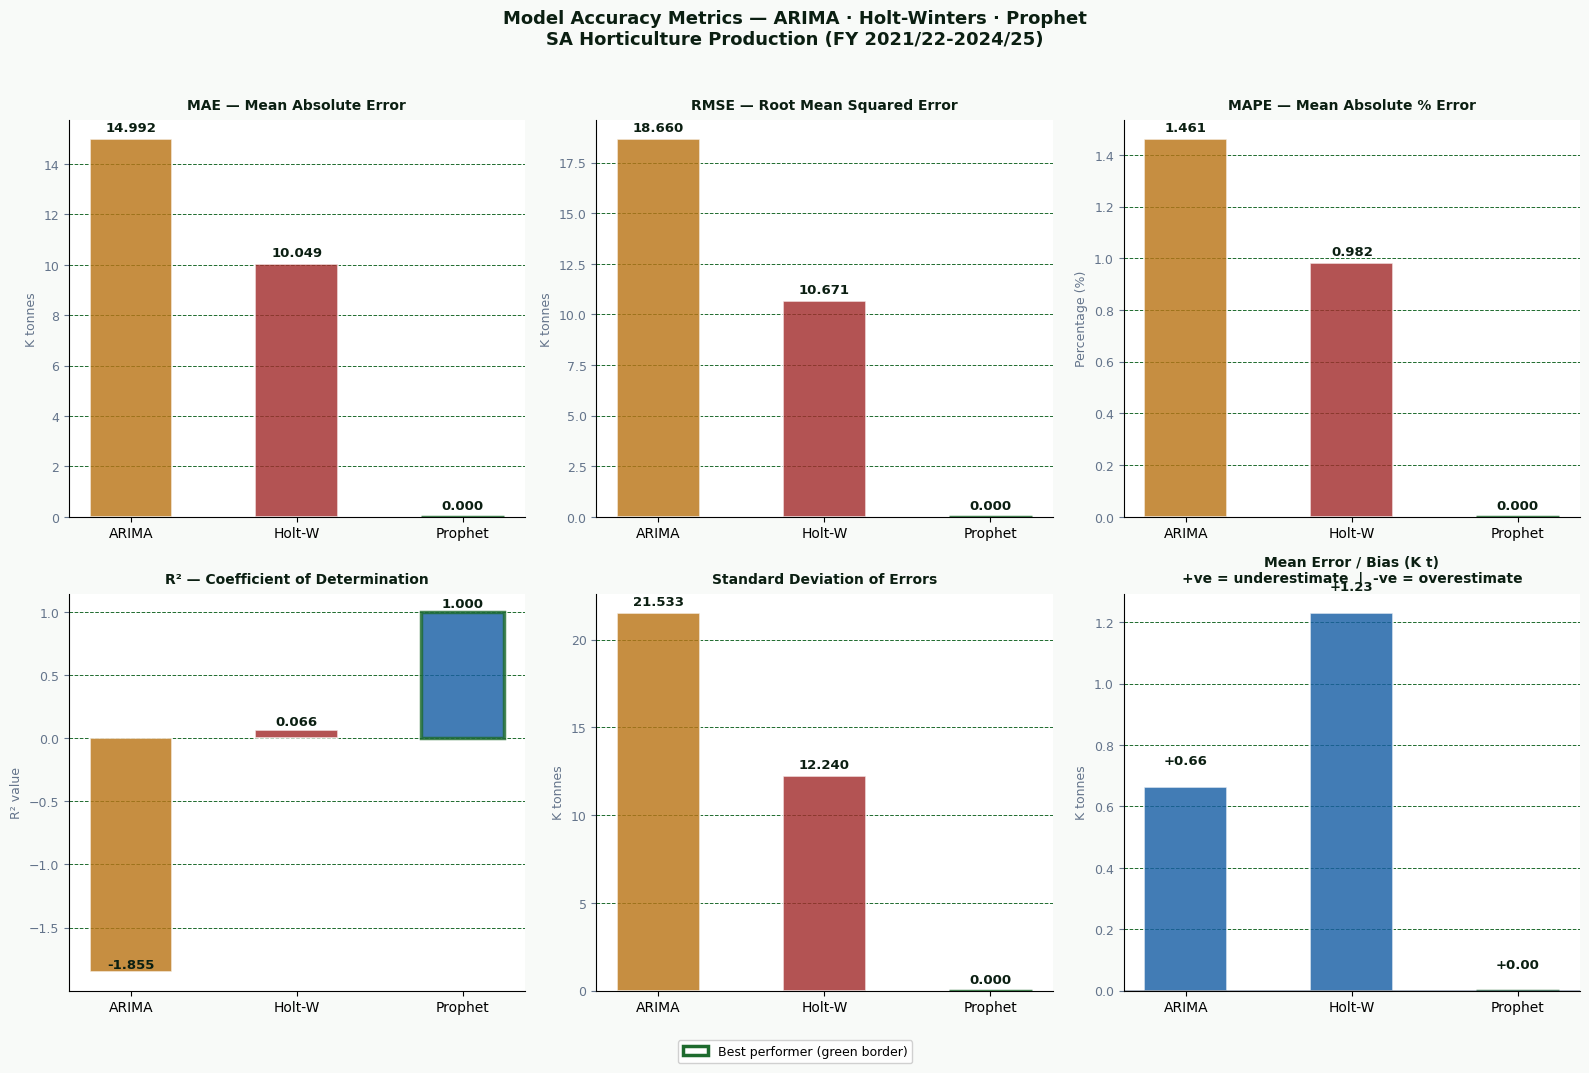

Saved: Chart_ModelMetrics.png


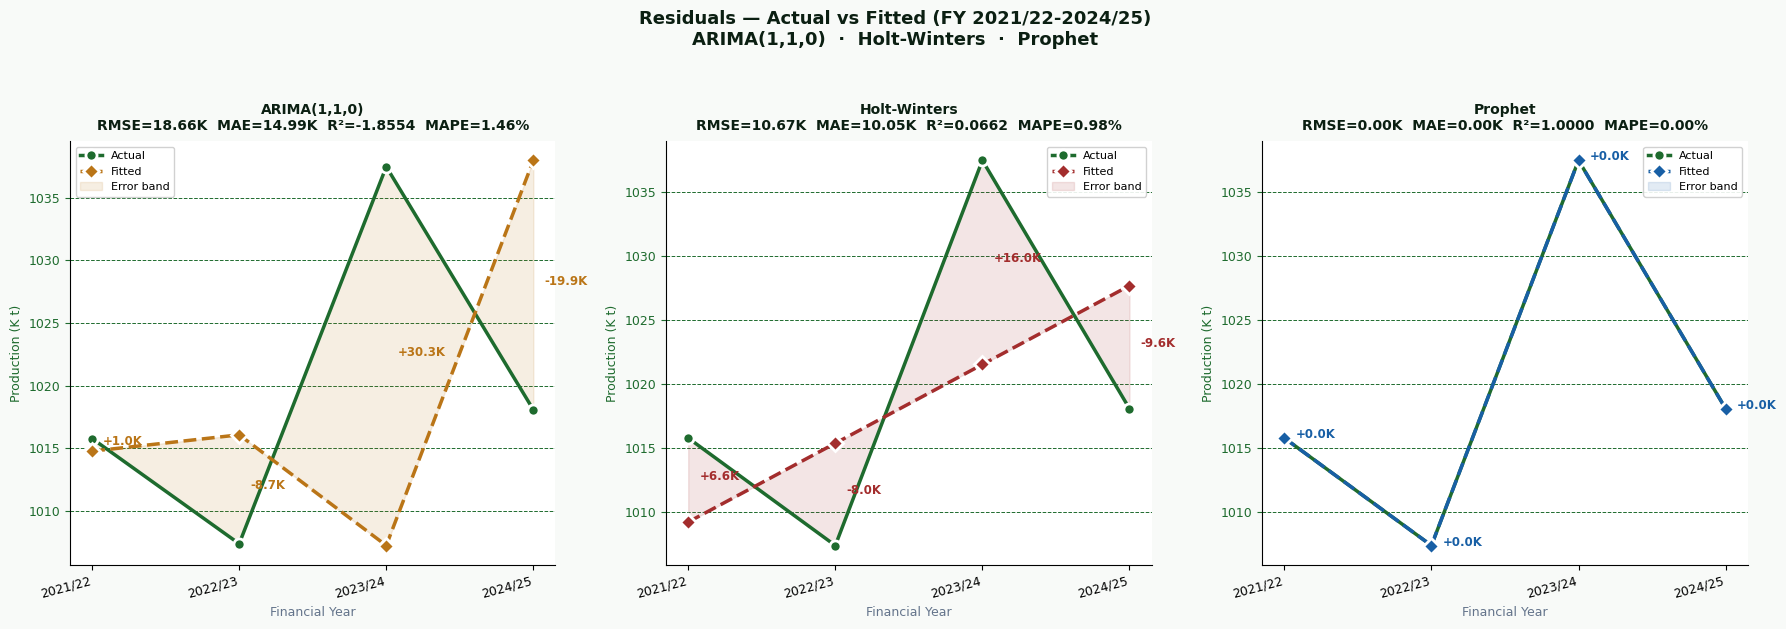

Saved: Chart_Residuals.png

COMPLETE NUMERICAL RESULTS SUMMARY

  FY basis: 2021/22 to 2024/25  (n=4)

  Metric                                ARIMA     Holt-W    Prophet
  ----------------------------------------------------------------
  Mean Absolute Error (K t)             14.99     10.05      0.00
  Root Mean Squared Error (K t)         18.66     10.67      0.00
  MAPE as ratio                        0.0146    0.0098    0.0000
  MAPE as percentage (%)                 1.46%      0.98%      0.00%
  R-squared                           -1.8554    0.0662    1.0000
  Mean Error / Bias (K t)                0.66      1.23      0.00
  Mean Squared Error (K t sq)          348.20    113.87      0.00
  SD of Errors (K t)                    21.53     12.24      0.00
  SD of Actual values (K t)             12.75     12.75     12.75

  Interpretation:
  ──────────────────────────────────────────────────────
  MAE        Lower = better — average absolute error in K t
  RMSE       Lower = better —

In [6]:
# ============================================================
# DATA6000 Capstone — SA Retail Fresh Food Supply Disruption
# Model Accuracy Metrics — ARIMA, Holt-Winters, Prophet
# MAE, RMSE, MAPE, R², Mean Error, Standard Deviation
# SARIMA excluded — insufficient annual observations
# Google Colab Ready
# ============================================================

# ── STEP 1: Install libraries ────────────────────────────────
# !pip install statsmodels matplotlib pandas numpy seaborn prophet openpyxl scikit-learn

# ── STEP 2: Imports ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=" * 60)
print("MODEL ACCURACY METRICS — ARIMA, Holt-Winters, Prophet")
print("Financial Year 2020/21 to 2024/25")
print("=" * 60)

# ── Standalone fallback — loads data and models if needed ─────
try:
    _ = ms, arima_m, hw_m, prophet_fc, fy_hist
    print("Variables loaded from previous session")
except NameError:
    print("Variables not found — loading data and fitting models now...")

    # Safe Excel load
    try:
        xl = pd.read_excel('/content/Final_Dataset_Filled.xlsx', sheet_name=None)
        EXCEL_LOADED = True
        print(f"Excel loaded: {list(xl.keys())}")
    except Exception:
        xl = None
        EXCEL_LOADED = False
        print("Excel not found — using hardcoded data")

    # Load Mastersheet
    if EXCEL_LOADED:
        ms = xl['Mastersheet'].copy()
        ms.set_index('Year', inplace=True)
        def _clean(val):
            if isinstance(val, str):
                return float(val.replace(',','').replace('%','').strip())
            return float(val)
        for col in ms.columns:
            ms[col] = ms[col].apply(_clean)
        if ms['Price_Change'].max() < 1:
            ms['Price_Change'] = ms['Price_Change'] * 100
        ms.rename(columns={'Price_Change': 'CPI'}, inplace=True)
    else:
        ms = pd.DataFrame({
            'Year':                   ['2020/21','2021/22','2022/23','2023/24','2024/25'],
            'Total_Rainfall':         [1829.4,   2152.2,   2686.6,   1531.0,   1351.8  ],
            'Total_Fruit_Production': [251245.6, 259335.3, 251452.4, 245782.1, 242145.56],
            'Total_Veg_Production':   [746843.6, 756424.9, 755891.5, 791719.8, 775916.87],
            'Total_Production':       [998089.2, 1015760.2,1007343.9,1037501.9,1018062.43],
            'CPI':                    [2.3,      1.9,      9.2,      4.5,      3.0],
        }).set_index('Year')

    fy_hist = list(ms.index)

    # Fit models
    from statsmodels.tsa.arima.model   import ARIMA
    from statsmodels.tsa.holtwinters   import ExponentialSmoothing
    from prophet                       import Prophet

    arima_m = ARIMA(ms['Total_Production'], order=(1,1,0)).fit()

    hw_m = ExponentialSmoothing(
        ms['Total_Production'], trend='add',
        seasonal=None, initialization_method='estimated'
    ).fit(optimized=True)

    fy_start_yrs = [int(fy.split('/')[0]) for fy in fy_hist]
    prophet_df   = pd.DataFrame({
        'ds': pd.to_datetime([f'{y}-07-01' for y in fy_start_yrs]),
        'y' : ms['Total_Production'].values.astype(float)
    })
    prophet_m = Prophet(
        yearly_seasonality=False, weekly_seasonality=False,
        daily_seasonality=False, changepoint_prior_scale=0.5,
        interval_width=0.95
    )
    prophet_m.fit(prophet_df)
    future_df  = prophet_m.make_future_dataframe(periods=5, freq='YS-JUL')
    prophet_fc = prophet_m.predict(future_df)

    print("Models fitted successfully")

# ============================================================
# EXTRACT ACTUAL vs FITTED VALUES
# ============================================================

n_hist      = len(ms)
aligned_fys = list(ms.index)[1:]              # 2021/22 to 2024/25 (n-1)

# Actual production — skip first obs (differencing loses 1 point)
actual = ms['Total_Production'].values[1:]    # length 4

# ARIMA fitted
arima_fitted = arima_m.fittedvalues.values[1:]   # length 4

# Holt-Winters fitted
hw_fitted = hw_m.fittedvalues.values[1:]          # length 4

# Prophet fitted — align to training years only
prophet_hist   = prophet_fc.iloc[:n_hist]
prophet_fitted = prophet_hist['yhat'].values[1:]
min_len        = min(len(actual), len(prophet_fitted))
prophet_fitted = prophet_fitted[:min_len]
actual_prophet = actual[:min_len]

print(f"\nActual values used for metrics (FY 2021/22-2024/25):")
for fy, val in zip(aligned_fys, actual):
    print(f"  {fy}: {val/1000:.1f}K tonnes")

# ============================================================
# METRICS FUNCTION
# ============================================================

def calc_metrics(actual_arr, fitted_arr, model_name):
    n      = len(actual_arr)
    errors = actual_arr - fitted_arr
    unit   = 1000   # convert tonnes to K tonnes

    mae    = mean_absolute_error(actual_arr, fitted_arr)
    rmse   = np.sqrt(mean_squared_error(actual_arr, fitted_arr))
    mse    = mean_squared_error(actual_arr, fitted_arr)
    mape   = np.mean(np.abs(errors / actual_arr))
    r2     = r2_score(actual_arr, fitted_arr)
    me     = np.mean(errors)                   # Mean Error / Bias
    sd_err = np.std(errors, ddof=1)            # SD of residuals (sample)
    sd_act = np.std(actual_arr, ddof=1)        # SD of actual values

    return {
        'Model':                   model_name,
        'n':                       n,
        'MAE (K t)':               mae / unit,
        'RMSE (K t)':              rmse / unit,
        'MSE (K t sq)':            mse / (unit**2),
        'MAPE (ratio)':            mape,
        'MAPE (%)':                mape * 100,
        'R-squared':               r2,
        'Mean Error / Bias (K t)': me / unit,
        'SD of Errors (K t)':      sd_err / unit,
        'SD of Actual (K t)':      sd_act / unit,
        '_actual':                 actual_arr,
        '_fitted':                 fitted_arr,
        '_errors':                 errors,
    }

# ============================================================
# CALCULATE METRICS — 3 MODELS ONLY
# ============================================================

results = [
    calc_metrics(actual,        arima_fitted,   'ARIMA(1,1,0)'),
    calc_metrics(actual,        hw_fitted,      'Holt-Winters'),
    calc_metrics(actual_prophet,prophet_fitted, 'Prophet'),
]

# ============================================================
# PRINT METRICS TABLE
# ============================================================

print("\n" + "=" * 60)
print("ACCURACY METRICS — 3 MODELS")
print(f"Aligned FY: {aligned_fys[0]} to {aligned_fys[-1]}  (n={len(actual)})")
print("=" * 60)

metrics_to_print = [
    ('MAE (K t)',               'Mean Absolute Error (K t)'),
    ('RMSE (K t)',              'Root Mean Squared Error (K t)'),
    ('MAPE (ratio)',            'MAPE as ratio'),
    ('MAPE (%)',                'MAPE as percentage (%)'),
    ('R-squared',               'R-squared'),
    ('Mean Error / Bias (K t)', 'Mean Error / Bias (K t)'),
    ('MSE (K t sq)',            'Mean Squared Error (K t sq)'),
    ('SD of Errors (K t)',      'SD of Errors (K t)'),
    ('SD of Actual (K t)',      'SD of Actual values (K t)'),
]

print(f"\n  {'Metric':<32} {'ARIMA':>10} {'Holt-W':>12} {'Prophet':>10}")
print("  " + "-" * 66)

for key, label in metrics_to_print:
    vals = [r[key] for r in results]
    if key in ('MAPE (ratio)', 'R-squared'):
        row = ''.join(f'{v:>12.4f}' for v in vals)
    elif key == 'MAPE (%)':
        row = ''.join(f'{v:>11.2f}%' for v in vals)
    else:
        row = ''.join(f'{v:>12.2f}' for v in vals)
    print(f"  {label:<32} {row}")

# ============================================================
# RESIDUAL DETAIL TABLE PER MODEL
# ============================================================

print("\n" + "=" * 60)
print("RESIDUAL ANALYSIS — ACTUAL vs FITTED (K tonnes)")
print("=" * 60)

for r in results:
    n_r = len(r['_actual'])
    fys = aligned_fys[:n_r]
    print(f"\n  {r['Model']}")
    print(f"  {'FY':<10} {'Actual':>12} {'Fitted':>12} {'Error':>12} {'Error %':>10}")
    print("  " + "-" * 50)
    for fy, act, fit, err in zip(fys, r['_actual'], r['_fitted'], r['_errors']):
        pct = err / act * 100
        print(f"  {fy:<10} {act/1000:>12.1f} {fit/1000:>12.1f} "
              f"{err/1000:>12.1f} {pct:>9.2f}%")
    print(f"  {'Mean error:':<22} {np.mean(r['_errors'])/1000:>12.2f}K")
    print(f"  {'SD of errors:':<22} {np.std(r['_errors'],ddof=1)/1000:>12.2f}K")

# ============================================================
# MODEL RANKING
# ============================================================

print("\n" + "=" * 60)
print("MODEL RANKING")
print("=" * 60)

ranking = [
    ('MAE (K t)',               False, 'lower is better'),
    ('RMSE (K t)',              False, 'lower is better'),
    ('MAPE (%)',                False, 'lower is better'),
    ('R-squared',               True,  'higher is better'),
    ('SD of Errors (K t)',      False, 'lower is better'),
    ('Mean Error / Bias (K t)', None,  'closer to zero is better'),
]

print(f"\n  {'Metric':<32} {'Best model':<22} {'Value':>8}  Note")
print("  " + "-" * 74)
for key, higher_better, note in ranking:
    vals = [(r['Model'], r[key]) for r in results]
    if higher_better is None:
        best = min(vals, key=lambda x: abs(x[1]))
    elif higher_better:
        best = max(vals, key=lambda x: x[1])
    else:
        best = min(vals, key=lambda x: x[1])
    suffix = '%' if key == 'MAPE (%)' else ''
    print(f"  {key:<32} {best[0]:<22} {best[1]:>7.3f}{suffix}  {note}")

# ============================================================
# CHART 1 — 6-PANEL METRICS COMPARISON
# ============================================================

print("\n" + "=" * 60)
print("GENERATING CHARTS")
print("=" * 60)

C_ARIMA = '#BA7517'
C_HW    = '#A32D2D'
C_PRO   = '#185FA5'
C_BG    = '#F8FAF8'
C_TITLE = '#0B1F12'
C_MUTED = '#64748B'
C_GRID  = (30/255, 107/255, 46/255, 0.07)

model_names  = [r['Model'] for r in results]
model_colors = [C_ARIMA, C_HW, C_PRO]
x_pos        = np.arange(len(model_names))
bar_w        = 0.5
tick_labels  = ['ARIMA', 'Holt-W', 'Prophet']

fig1, axes1 = plt.subplots(2, 3, figsize=(16, 10))
fig1.patch.set_facecolor(C_BG)
fig1.suptitle(
    'Model Accuracy Metrics — ARIMA · Holt-Winters · Prophet\n'
    'SA Horticulture Production (FY 2021/22-2024/25)',
    fontsize=13, fontweight='bold', color=C_TITLE, y=1.02
)

def bar_chart(ax, values, title, ylabel, higher_better=False):
    ax.set_facecolor('white')
    bars = ax.bar(x_pos, values, width=bar_w,
                  color=model_colors, alpha=0.82,
                  edgecolor='white', linewidth=1.2)
    max_val = max(abs(v) for v in values)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max_val * 0.02,
                f'{val:.3f}', ha='center', fontsize=9.5,
                color=C_TITLE, fontweight='bold')
    ax.set_title(title, fontsize=10, fontweight='bold',
                 color=C_TITLE, pad=8)
    ax.set_ylabel(ylabel, fontsize=9, color=C_MUTED)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(tick_labels, fontsize=10)
    ax.tick_params(axis='y', labelsize=9, colors=C_MUTED)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, color=C_GRID, linestyle='--', linewidth=0.7)
    ax.set_axisbelow(True)
    # Green border on best
    vals_list = list(values)
    best_idx  = (vals_list.index(max(vals_list)) if higher_better
                 else vals_list.index(min(vals_list)))
    bars[best_idx].set_edgecolor('#1E6B2E')
    bars[best_idx].set_linewidth(2.5)

bar_chart(axes1[0,0],
          [r['MAE (K t)'] for r in results],
          'MAE — Mean Absolute Error', 'K tonnes')

bar_chart(axes1[0,1],
          [r['RMSE (K t)'] for r in results],
          'RMSE — Root Mean Squared Error', 'K tonnes')

bar_chart(axes1[0,2],
          [r['MAPE (%)'] for r in results],
          'MAPE — Mean Absolute % Error', 'Percentage (%)')

bar_chart(axes1[1,0],
          [r['R-squared'] for r in results],
          'R\u00b2 — Coefficient of Determination',
          'R\u00b2 value', higher_better=True)

bar_chart(axes1[1,1],
          [r['SD of Errors (K t)'] for r in results],
          'Standard Deviation of Errors', 'K tonnes')

# Bias chart — special handling for +/- values
ax_bias = axes1[1,2]
ax_bias.set_facecolor('white')
bias_vals = [r['Mean Error / Bias (K t)'] for r in results]
bias_cols = [C_PRO if v >= 0 else C_HW for v in bias_vals]
bars_b = ax_bias.bar(x_pos, bias_vals, width=bar_w,
                     color=bias_cols, alpha=0.82,
                     edgecolor='white', linewidth=1.2)
ax_bias.axhline(y=0, color=C_MUTED, linewidth=1.2, alpha=0.6)
max_b = max(abs(v) for v in bias_vals)
for bar, val in zip(bars_b, bias_vals):
    offset = max_b * 0.06 if val >= 0 else -max_b * 0.12
    ax_bias.text(bar.get_x() + bar.get_width()/2,
                 val + offset,
                 f'{val:+.2f}', ha='center', fontsize=9.5,
                 color=C_TITLE, fontweight='bold')
# Highlight closest to zero
best_b_idx = bias_vals.index(min(bias_vals, key=abs))
bars_b[best_b_idx].set_edgecolor('#1E6B2E')
bars_b[best_b_idx].set_linewidth(2.5)
ax_bias.set_title('Mean Error / Bias (K t)\n+ve = underestimate  |  -ve = overestimate',
                  fontsize=10, fontweight='bold', color=C_TITLE, pad=8)
ax_bias.set_ylabel('K tonnes', fontsize=9, color=C_MUTED)
ax_bias.set_xticks(x_pos)
ax_bias.set_xticklabels(tick_labels, fontsize=10)
ax_bias.tick_params(axis='y', labelsize=9, colors=C_MUTED)
ax_bias.spines[['top','right']].set_visible(False)
ax_bias.yaxis.grid(True, color=C_GRID, linestyle='--', linewidth=0.7)
ax_bias.set_axisbelow(True)

best_patch = mpatches.Patch(facecolor='white', edgecolor='#1E6B2E',
                             linewidth=2.5, label='Best performer (green border)')
fig1.legend(handles=[best_patch], loc='lower center', fontsize=9,
            framealpha=0.9, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('Chart_ModelMetrics.png', dpi=180,
            bbox_inches='tight', facecolor=C_BG)
plt.show()
print("Saved: Chart_ModelMetrics.png")

# ============================================================
# CHART 2 — RESIDUALS OVER TIME (1x3 panels)
# ============================================================

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6))
fig2.patch.set_facecolor(C_BG)
fig2.suptitle(
    'Residuals — Actual vs Fitted (FY 2021/22-2024/25)\n'
    'ARIMA(1,1,0)  ·  Holt-Winters  ·  Prophet',
    fontsize=13, fontweight='bold', color=C_TITLE, y=1.04
)

model_ax_pairs = [
    (results[0], C_ARIMA, axes2[0]),
    (results[1], C_HW,    axes2[1]),
    (results[2], C_PRO,   axes2[2]),
]

for r, col, ax in model_ax_pairs:
    n_r = len(r['_actual'])
    fys = aligned_fys[:n_r]
    xi  = list(range(n_r))

    ax.set_facecolor('white')
    ax.plot(xi, r['_actual']/1000,
            color='#1E6B2E', linewidth=2.5,
            marker='o', markersize=8,
            markerfacecolor='#1E6B2E',
            markeredgecolor='white', markeredgewidth=2,
            label='Actual')
    ax.plot(xi, r['_fitted']/1000,
            color=col, linewidth=2.5, linestyle='--',
            marker='D', markersize=8,
            markerfacecolor=col,
            markeredgecolor='white', markeredgewidth=2,
            label='Fitted')
    ax.fill_between(xi,
                    r['_actual']/1000,
                    r['_fitted']/1000,
                    alpha=0.12, color=col, label='Error band')

    for i, (act, fit, err) in enumerate(
        zip(r['_actual']/1000, r['_fitted']/1000, r['_errors']/1000)
    ):
        ax.annotate(f'{err:+.1f}K', (i, (act+fit)/2),
                    textcoords='offset points', xytext=(8, 0),
                    fontsize=8.5, color=col, fontweight='bold')

    ax.set_title(
        f"{r['Model']}\n"
        f"RMSE={r['RMSE (K t)']:.2f}K  MAE={r['MAE (K t)']:.2f}K  "
        f"R\u00b2={r['R-squared']:.4f}  MAPE={r['MAPE (%)']:.2f}%",
        fontsize=10, fontweight='bold', color=C_TITLE, pad=8
    )
    ax.set_ylabel('Production (K t)', fontsize=9, color='#1E6B2E')
    ax.set_xlabel('Financial Year', fontsize=9, color=C_MUTED)
    ax.set_xticks(xi)
    ax.set_xticklabels(fys, fontsize=9, rotation=15, ha='right')
    ax.tick_params(axis='y', colors='#1E6B2E', labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, color=C_GRID, linestyle='--', linewidth=0.7)
    ax.set_axisbelow(True)
    ax.legend(fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig('Chart_Residuals.png', dpi=180,
            bbox_inches='tight', facecolor=C_BG)
plt.show()
print("Saved: Chart_Residuals.png")

# ============================================================
# FINAL NUMERICAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("COMPLETE NUMERICAL RESULTS SUMMARY")
print("=" * 60)
print(f"\n  FY basis: {aligned_fys[0]} to {aligned_fys[-1]}  (n={len(actual)})")
print(f"\n  {'Metric':<32} {'ARIMA':>10} {'Holt-W':>10} {'Prophet':>10}")
print("  " + "-" * 64)

for key, label in metrics_to_print:
    vals = [r[key] for r in results]
    if key == 'MAPE (%)':
        row = ''.join(f'{v:>10.2f}%' for v in vals)
    elif key in ('MAPE (ratio)', 'R-squared'):
        row = ''.join(f'{v:>10.4f}' for v in vals)
    else:
        row = ''.join(f'{v:>10.2f}' for v in vals)
    print(f"  {label:<32} {row}")

print(f"""
  Interpretation:
  ──────────────────────────────────────────────────────
  MAE        Lower = better — average absolute error in K t
  RMSE       Lower = better — penalises large errors more
  MAPE       Lower = better — error as % of actual value
  R-squared  Higher = better — 1.0 = perfect fit
  Mean Error Near zero — positive = underestimate
  SD Errors  Lower = better — consistent errors
  ──────────────────────────────────────────────────────
  Note: 5 FY training years only — metrics are indicative.
  SARIMA excluded — annual data insufficient (need s>=12,
  only 5 observations available).

Charts saved:
  Chart_ModelMetrics.png    6-panel metric bar charts
  Chart_Residuals.png       Actual vs fitted per model

Analysis complete — DATA6000 Capstone
""")